#1


La frecuencia de Rabi $\Omega_R$ está dada por la fórmula:
$$\Omega_R^2 = \Omega^2 + \left(\frac{\Omega_R}{2}\right)^2$$

Siendo$\left(\frac{\Omega_R}{2}\right)$ la frecuencia de desafinación, de aquí:

$$\Omega_R^2 = \Omega^2 + \frac{\Omega_R^2}{4}$$$$\frac{3}{4}\Omega_R^2 = \Omega^2$$$$\Omega_R = \frac{2}{\sqrt{3}}\Omega$$


Esta frecuencia en Hz es:
$$f_R = \frac{\Omega_R}{2\pi} = \frac{2}{\sqrt{3}} \left(\frac{\Omega}{2\pi}\right)$$$$f_R = \frac{2}{\sqrt{3}} \times 24.79 \text{ GHz} \approx 28.625 \text{ GHz}$$

La probabilidad de que un sistema transicione de un estado  $|2\rangle$  un estado  $|1\rangle$ es:

$$P_{2 \to 1}(t) = \left(\frac{\Omega}{\Omega_R}\right)^2 \sin^2\left(\frac{\Omega_R t}{2}\right)$$

sí la probabilidad de mantenerse en el estado  $|2\rangle$ es:

$$P_2(t) = 1 - P_{2 \to 1}(t) = 1 - 0.75 \sin^2\left(\pi f_R t\right)$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

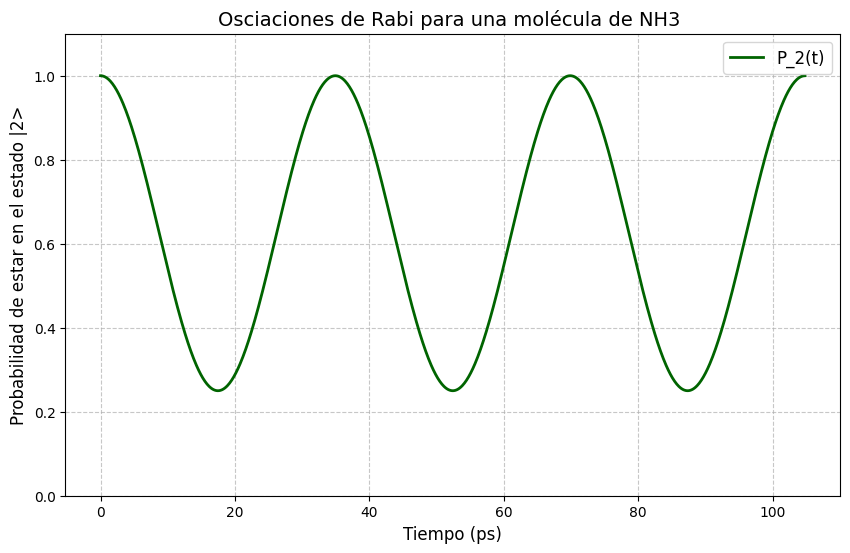

In [4]:

f_R = 28.625e9

T = 1 / f_R
t = np.linspace(0, 3 * T, 1000)

P_2 = 1 - 0.75 * np.sin(np.pi * f_R * t)**2


plt.figure(figsize=(10, 6))
plt.plot(t * 1e12, P_2, color='darkgreen', linewidth=2, label='P_2(t)')
plt.title('Osciaciones de Rabi para una molécula de NH3 ', fontsize=14)
plt.xlabel('Tiempo (ps)', fontsize=12)
plt.ylabel('Probabilidad de estar en el estado |2>', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=12)
plt.show()

#2

In [6]:
pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.0 MB/s eta 0:00:00


In [15]:
!pip install qiskit_aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=9c6ca04f8aae689b079bf88aaaffe3a8b9b57fe2a4ed27b22b99bb909ddfa608
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


1)

In [22]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

simulator = Aer.get_backend('qasm_simulator')

qc1 = QuantumCircuit(2, 2)
qc1.h(0)
qc1.cx(0, 1)
qc1.measure([0, 1], [0, 1])

result1 = simulator.run(qc1).result()
counts1 = result1.get_counts(qc1)

print(qc.draw(output='text'))


     ┌───┐          ┌─┐        
q_0: ┤ H ├──■───────┤M├────────
     └───┘┌─┴─┐     └╥┘┌───┐┌─┐
q_1: ─────┤ X ├──■───╫─┤ X ├┤M├
          └───┘┌─┴─┐ ║ └┬─┬┘└╥┘
q_2: ──────────┤ X ├─╫──┤M├──╫─
               └───┘ ║  └╥┘  ║ 
c: 3/════════════════╩═══╩═══╩═
                     0   2   1 


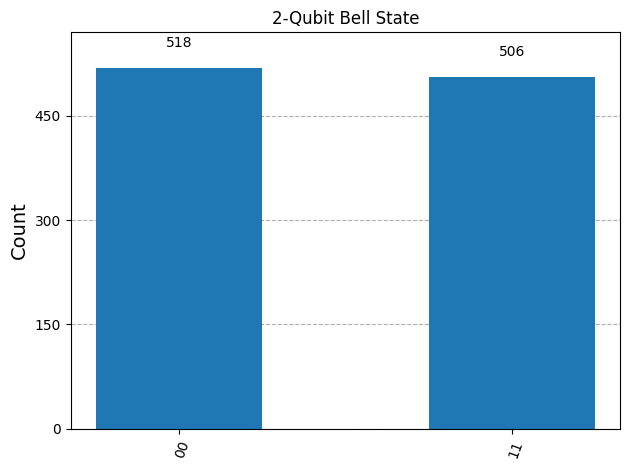

In [24]:
plot_histogram(counts1, title="2-Qubit Bell State")

2.

In [21]:
simulator = Aer.get_backend('qasm_simulator')


qc2 = QuantumCircuit(3, 3)
qc2.h(0)
qc2.cx(0, 1)
qc2.cx(1, 2)
qc2.measure([0, 1, 2], [0, 1, 2])


result2 = simulator.run(qc2).result()
counts2 = result2.get_counts(qc2)



print(qc.draw(output='text'))

     ┌───┐          ┌─┐        
q_0: ┤ H ├──■───────┤M├────────
     └───┘┌─┴─┐     └╥┘┌───┐┌─┐
q_1: ─────┤ X ├──■───╫─┤ X ├┤M├
          └───┘┌─┴─┐ ║ └┬─┬┘└╥┘
q_2: ──────────┤ X ├─╫──┤M├──╫─
               └───┘ ║  └╥┘  ║ 
c: 3/════════════════╩═══╩═══╩═
                     0   2   1 


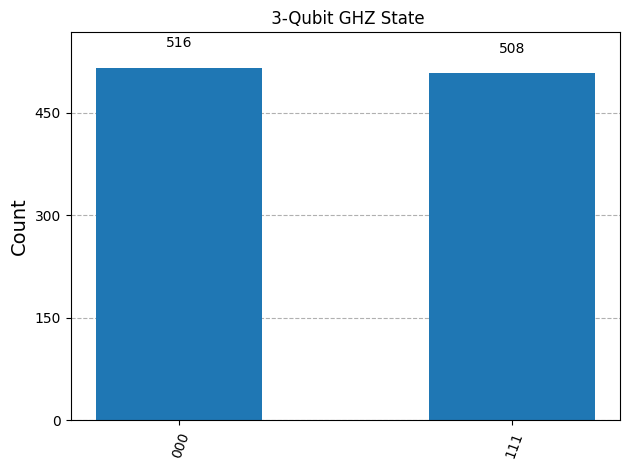

In [25]:
plot_histogram(counts2, title=" 3-Qubit GHZ State")

3.

In [30]:

simulator = Aer.get_backend('qasm_simulator')


qc3 = QuantumCircuit(3, 3)
qc3.h(0)
qc3.cx(0, 1)
qc3.cx(1, 2)


qc3.x(1)

qc3.measure([0, 1, 2], [0, 1, 2])


result3 = simulator.run(qc3).result()
counts3 = result3.get_counts(qc3)


print(qc.draw(output='text'))

     ┌───┐          ┌─┐        
q_0: ┤ H ├──■───────┤M├────────
     └───┘┌─┴─┐     └╥┘┌───┐┌─┐
q_1: ─────┤ X ├──■───╫─┤ X ├┤M├
          └───┘┌─┴─┐ ║ └┬─┬┘└╥┘
q_2: ──────────┤ X ├─╫──┤M├──╫─
               └───┘ ║  └╥┘  ║ 
c: 3/════════════════╩═══╩═══╩═
                     0   2   1 


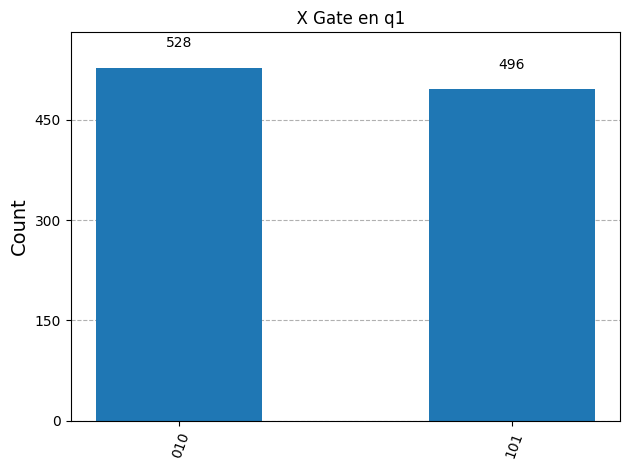

In [31]:
plot_histogram(counts3, title="  X Gate en q1")